In [1]:
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr, kruskal
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

In [29]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
numeric_clinical = clinical_df.select_dtypes(include=['number']).columns

features_df = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
numeric_features = features_df.select_dtypes(include=['number']).columns

🔵 CORRELATION BETWEEN CLINICAL DATA AND IMAGE FEATURES

In [30]:
scaler = StandardScaler()

clinical_scaled = pd.DataFrame(scaler.fit_transform(clinical_df[numeric_clinical]),
                               columns=clinical_df[numeric_clinical].columns,
                               index=clinical_df[numeric_clinical].index)

features_scaled = pd.DataFrame(scaler.fit_transform(features_df[numeric_features]),
                               columns=features_df[numeric_features].columns,
                               index=features_df[numeric_features].index)

In [31]:
clinical_column = 'Beta2 microglobulin (mg/l)'

spearman_corr = {}

for col in numeric_features:
    valid_idx = features_scaled[col].notna() & clinical_scaled[clinical_column].notna()
    corr, p_value = spearmanr(features_scaled[col][valid_idx], clinical_scaled[clinical_column][valid_idx])
    spearman_corr[col] = {'spearman_corr': corr, 'p_value': p_value, 'significant': p_value < 0.05}

spearman_df = pd.DataFrame(spearman_corr).T
spearman_df = spearman_df.sort_values(by='spearman_corr', ascending=False)
spearman_df

,spearman_corr,p_value,significant
original_glcm_Idm,0.505298,0.00001,True
original_glcm_Id,0.504476,0.00001,True
gradient_gldm_LowGrayLevelEmphasis,0.498429,0.000013,True
gradient_glrlm_LongRunLowGrayLevelEmphasis,0.486518,0.000022,True
gradient_glrlm_LowGrayLevelRunEmphasis,0.485951,0.000023,True
...,...,...,...
original_glrlm_RunLengthNonUniformityNormalized,-0.476945,0.000034,True
original_glcm_DifferenceEntropy,-0.477913,0.000033,True
original_glrlm_ShortRunEmphasis,-0.478571,0.000032,True
original_glcm_DifferenceAverage,-0.482882,0.000026,True


🔵 Save spearman coefficients to csv

In [128]:
# output_path = r"D:\CSV\spearman_coef\spearman_results_vmi40.csv"
# spearman_df.to_csv(output_path, index=True)

🔵 MUTUAL INFORMATION BETWEEN SELECTED BIOMARKER AND ALL IMAGE FEATURES

In [5]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_column = 'Beta2 microglobulin (mg/l)'   # Serum M-protein quantity (g/l)

features_df = pd.read_csv(r"D:\CSV\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
numeric_features = features_df.select_dtypes(include=['number']).columns


mutual_info = {}

for col in numeric_features:
    valid_idx = features_df[col].notna() & clinical_df[clinical_column].notna()

    X = features_df[[col]][valid_idx]
    y = clinical_df[clinical_column][valid_idx]

    mi = mutual_info_regression(X, y)[0]
    mutual_info[col] = {'MI': mi}

mi_df = pd.DataFrame(mutual_info).T
mi_df = mi_df.sort_values(by='MI', ascending=False)

# pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')
mi_df

,MI
original_glrlm_RunVariance,0.374666
original_gldm_LargeDependenceEmphasis,0.351175
original_gldm_DependenceNonUniformityNormalized,0.327315
gradient_gldm_LargeDependenceLowGrayLevelEmphasis,0.324057
original_glcm_SumSquares,0.262021
...,...
gradient_glszm_SizeZoneNonUniformity,0.000000
gradient_glszm_LargeAreaHighGrayLevelEmphasis,0.000000
gradient_gldm_LargeDependenceHighGrayLevelEmphasis,0.000000
gradient_ngtdm_Coarseness,0.000000


🔵 BOXPLOT FOR STAGE AND SELECTED IMAGE FEATURES

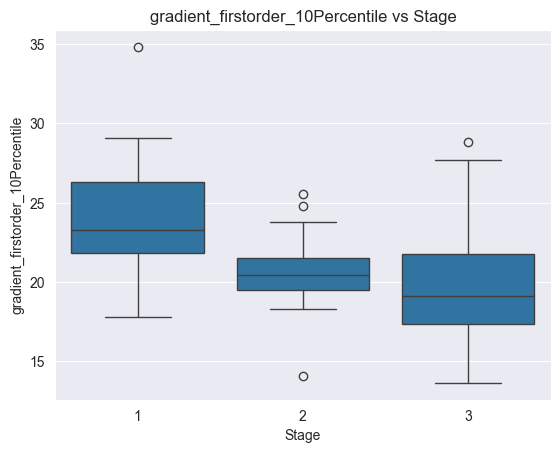

In [36]:
pd.set_option('future.no_silent_downcasting', True)
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

img_feature = "gradient_firstorder_10Percentile"  # original_firstorder_Range -> useless

data = pd.concat([features_df[img_feature], clinical_df['Stage']], axis=1).dropna()
sns.boxplot(x='Stage', y=img_feature, data=data)
plt.xlabel('Stage')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs Stage')
plt.show()

🔵 LASSO REGULARIZATION FOR FEATURE SELECTION

In [8]:
from sklearn.linear_model import Lasso

valid_idx = clinical_scaled['Beta2 microglobulin (mg/l)'].notna()

lasso = Lasso(alpha=0.01)
X = features_scaled[numeric_features][valid_idx]
y = clinical_scaled['Beta2 microglobulin (mg/l)'][valid_idx]
lasso.fit(X, y)

print("R^2 score Lasso:", lasso.score(X, y))
feature_weights = pd.Series(lasso.coef_, index=X.columns)
feature_weights

R^2 score Lasso: 0.8317476996272839


n_lesions                        -0.485925
original_shape_Elongation        -0.000000
original_shape_Flatness          -0.000000
original_shape_LeastAxisLength    0.179611
original_shape_MajorAxisLength    1.022180
                                    ...   
gradient_ngtdm_Busyness           0.000000
gradient_ngtdm_Coarseness        -0.013310
gradient_ngtdm_Complexity        -0.000000
gradient_ngtdm_Contrast          -0.000000
gradient_ngtdm_Strength          -0.000000
Length: 201, dtype: float64

In [13]:
combined_feature = X.dot(feature_weights)
corr, p_value = spearmanr(combined_feature, y)
print(f"Spearmanova korelácia kombinovaného príznaku: {corr:.3f}")
print(f"P-hodnota: {p_value:.3e} | Significant {p_value < 0.05}")

Spearmanova korelácia kombinovaného príznaku: 0.750
P-hodnota: 1.154e-13 | Significant True


In [14]:
combined_feature = X.sum(axis=1)
corr, p_value = spearmanr(combined_feature, y)
print(f"Spearmanova korelácia kombinovaného príznaku (váhy=1): {corr:.3f}")
print(f"P-hodnota: {p_value:.3e} | Significant {p_value < 0.05}")

Spearmanova korelácia kombinovaného príznaku (váhy=1): -0.159
P-hodnota: 1.914e-01 | Significant False


🔵 BOXPLOT BETWEEN STAGE AND EVERY FEATURE

In [ ]:
pd.set_option('future.no_silent_downcasting', True)
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

numeric_features = features_df.select_dtypes(include=['number']).columns

for feature in numeric_features:

    data = pd.concat([features_df[feature], clinical_df['Stage']], axis=1).dropna()
    stage1 = data[data['Stage'] == 1][feature].dropna()
    stage2 = data[data['Stage'] == 2][feature].dropna()
    stage3 = data[data['Stage'] == 3][feature].dropna()

    stat, p_value = kruskal(stage1, stage2, stage3)
    print(f"Kruskal-Wallis: {feature} -> H = {stat:.3f}, p = {p_value:.4f} => Significant: {p_value < 0.05}")

    # VISUALIZATION
    sns.boxplot(x='Stage', y=feature, data=data)
    plt.xlabel('Stage')
    plt.ylabel(feature)
    plt.title(f'{feature} vs Stage')
    plt.show()

🔵 KRUSKAL-WALLIS TEST BETWEEN EACH STAGE GROUP PAIR

In [55]:
pd.set_option('future.no_silent_downcasting', True)
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

features_df = pd.read_csv(r"D:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
numeric_features = features_df.select_dtypes(include=['number']).columns

results = []

for feature in numeric_features:

    data = pd.concat([features_df[feature], clinical_df['Stage']], axis=1).dropna()
    stage1 = data[data['Stage'] == 1][feature].dropna()
    stage2 = data[data['Stage'] == 2][feature].dropna()
    stage3 = data[data['Stage'] == 3][feature].dropna()

    stat, p_value = kruskal(stage1, stage2, stage3)
    stat12, p_value12 = kruskal(stage1, stage2)
    stat13, p_value13 = kruskal(stage1, stage3)
    stat23, p_value23 = kruskal(stage2, stage3)

    results.append({
        "Feature": feature,
        "H_all": stat,
        "p_all": p_value,
        "p(1-2)": p_value12,
        "p(1-3)": p_value13,
        "p(2-3)": p_value23,
    })

# results_df = pd.DataFrame(results)
# results_df.to_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_CaSupp_25.csv", index=False)